# **Prediksi Status Lokasi | Random Forest**

> Model prediksi status Lokasi berdasarkan kekuatan sinyal _bluetooth_ yang dihasilkan dari perangkat itag menggunakan alrogitma Random Forest

## 1. Data Understanding

### 1.1 Import the Libraries

In [144]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import tkinter as tk

from tkinter import messagebox, ttk


### 1.2 Read the Dataset 

In [145]:
# Import the csv dataset
bt1 = pd.read_csv('raw_rssi.csv')

# Show the top 5 of dataset 
print('\nTop 5 rows of dataset:')
bt1.head()


Top 5 rows of dataset:


,name,locationStatus,timestamp,rssiOne,rssiTwo
0,FF:FF:C0:21:F1:31,INSIDE,1551367495147,-90,-90
1,FF:FF:C0:21:EF:BA,INSIDE,1551367496681,-93,-93
2,FF:FF:C0:21:EF:1A,INSIDE,1551367495114,-88,-88
3,FF:FF:C0:21:EF:BF,INSIDE,1551367497508,-82,-82
4,FF:FF:C0:21:F1:31,INSIDE,1551367496906,-94,-94


In [146]:
# Show the information of dataset
print('\nInformation of dataset:')
bt1.info()


Information of dataset:
<class 'pandas.DataFrame'>
RangeIndex: 13588 entries, 0 to 13587
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   name            13588 non-null  str  
 1   locationStatus  13588 non-null  str  
 2   timestamp       13588 non-null  int64
 3   rssiOne         13588 non-null  str  
 4   rssiTwo         13588 non-null  str  
dtypes: int64(1), str(4)
memory usage: 530.9 KB


In [147]:
# Show the dimensional dataset
print('\nNumber of rows:', bt1.shape[0])
print('Number of columns:', bt1.shape[1])


Number of rows: 13588
Number of columns: 5


In [148]:
# show the number of unique values
bt1.nunique()

name                12
locationStatus       5
timestamp         9068
rssiOne             59
rssiTwo             55
dtype: int64

In [149]:
# Show the unique values per features
for col in bt1.columns:
    print(f'\nUnique values the {col} feature:', bt1[col].unique())


Unique values the name feature: <StringArray>
['FF:FF:C0:21:F1:31', 'FF:FF:C0:21:EF:BA', 'FF:FF:C0:21:EF:1A',
 'FF:FF:C0:21:EF:BF', 'FF:FF:C0:21:F1:2B', 'FF:FF:C2:1E:05:19',
 'FF:FF:C2:1E:02:D2', 'FF:FF:C0:21:EF:A4', 'FF:FF:C2:1D:9B:54',
 'FF:FF:C2:1D:9B:71', 'FF:FF:C2:1D:9B:52', 'FF:FF:C0:22:3D:C1']
Length: 12, dtype: str

Unique values the locationStatus feature: <StringArray>
['INSIDE', 'inside', 'IN_VESTIBULE', 'in_vestibule', 'OUTSIDE']
Length: 5, dtype: str

Unique values the timestamp feature: [1551367495147 1551367496681 1551367495114 ... 1551368694032 1551368694210
 1551368694011]

Unique values the rssiOne feature: <StringArray>
[ '-90',  '-93',  '-88',  '-82',  '-94',  '-96',  '-95',  '-80',  '-79',
  '-92',  '-86',  '-89',  '-91',  '-84',  '-87',  '-85',  '-97', '-105',
  '-83',  '-81',  '-74',  '-77',  '-76',  '-75',  '-78',  '-73',  '-98',
 '-102',  '-72',  '-99', '-101', '-103', '-100',  '-71',  '-9e', '-1o3',
  '-8e',  '-9a',  '-8g',  '-9i',  '-70',  '-68',  '-69',  '-

In [150]:
# Show the number of missing value and duplicated data
print('\nNumber of missing values:', bt1.isnull().sum().sum())
print('Number of duplicated data:', bt1.duplicated().sum())


Number of missing values: 0
Number of duplicated data: 2829


In [151]:
# Show the rows that have a duplicated data
bt1[bt1.duplicated()]

,name,locationStatus,timestamp,rssiOne,rssiTwo
5,FF:FF:C0:21:EF:BA,INSIDE,1551367496681,-93,-93
7,FF:FF:C0:21:EF:BF,INSIDE,1551367497508,-82,-82
11,FF:FF:C0:21:EF:BF,INSIDE,1551367497508,-82,-82
12,FF:FF:C0:21:F1:31,INSIDE,1551367501157,-95,-95
13,FF:FF:C0:21:EF:BA,INSIDE,1551367500949,-80,-80
...,...,...,...,...,...
13466,FF:FF:C2:1D:9B:54,OUTSIDE,1551368664764,-86,-86
13484,FF:FF:C2:1D:9B:52,OUTSIDE,1551368669915,-87,-87
13516,FF:FF:C2:1D:9B:52,OUTSIDE,1551368678049,-84,-84
13520,FF:FF:C2:1D:9B:52,OUTSIDE,1551368678049,-84,-84


In [152]:
cat_cols = bt1.drop('timestamp', axis=1)

## 2. Exploaratory Data Analysis

### 2.1 Multivariate Analysis

#### Statistical Summary

In [153]:
print('\nStatistical summary of numerical features:')
bt1['timestamp'].describe()


Statistical summary of numerical features:


count    1.358800e+04
mean     1.551368e+12
std      3.410914e+05
min      1.551367e+12
25%      1.551368e+12
50%      1.551368e+12
75%      1.551368e+12
max      1.551369e+12
Name: timestamp, dtype: float64

In [154]:
print('\nStatistical summary of categorical features:')
cat_cols.describe()


Statistical summary of categorical features:


,name,locationStatus,rssiOne,rssiTwo
count,13588,13588,13588,13588
unique,12,5,59,55
top,FF:FF:C0:21:F1:2B,OUTSIDE,-86,-86
freq,1198,4619,892,892


### 2.2 Univariate Analysis

#### Numerical Feature Distribution

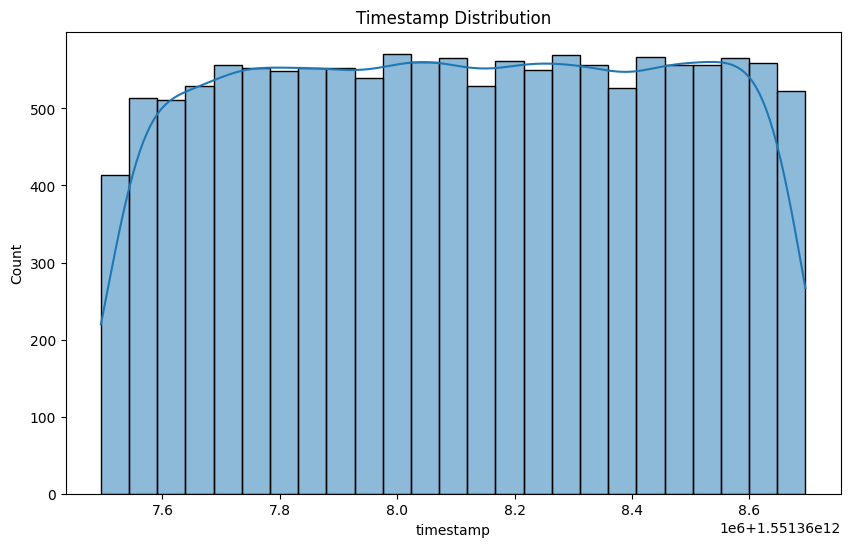

In [155]:
# Timestamp distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=bt1, x='timestamp', kde=True)
plt.title('Timestamp Distribution')
plt.show()

In [156]:
# convert the unix timestamp to datetime
bt1['datetime'] = pd.to_datetime(bt1['timestamp'], unit='ms')
bt1['datetime'].head(10)

0   2019-02-28 15:24:55.147
1   2019-02-28 15:24:56.681
2   2019-02-28 15:24:55.114
3   2019-02-28 15:24:57.508
4   2019-02-28 15:24:56.906
5   2019-02-28 15:24:56.681
6   2019-02-28 15:24:56.026
7   2019-02-28 15:24:57.508
8   2019-02-28 15:25:01.157
9   2019-02-28 15:25:00.949
Name: datetime, dtype: datetime64[ms]

In [157]:
print(bt1['datetime'].min())
print(bt1['datetime'].max())

2019-02-28 15:24:55.114000
2019-02-28 15:44:55.288000


#### Categorical Features Distribution

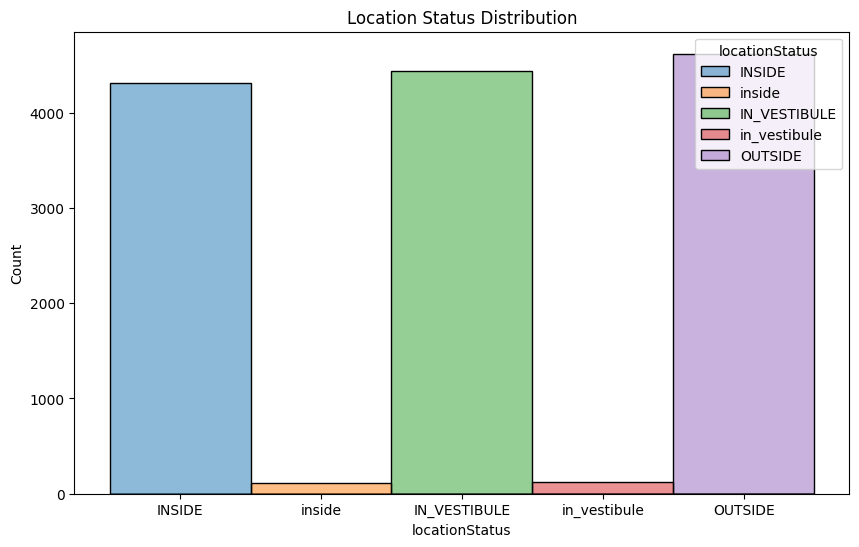

In [158]:
# Target distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=bt1, x='locationStatus', kde=True, hue='locationStatus')
plt.title('Location Status Distribution')
plt.show()

In [159]:
# Show the number of target distribution 
bt1['locationStatus'].value_counts()

locationStatus
OUTSIDE         4619
IN_VESTIBULE    4435
INSIDE          4305
in_vestibule     118
inside           111
Name: count, dtype: int64

In [160]:
in_vestibule = 4435 + 118 
inside = 4305 + 111
print(in_vestibule)
print(inside)

4553
4416


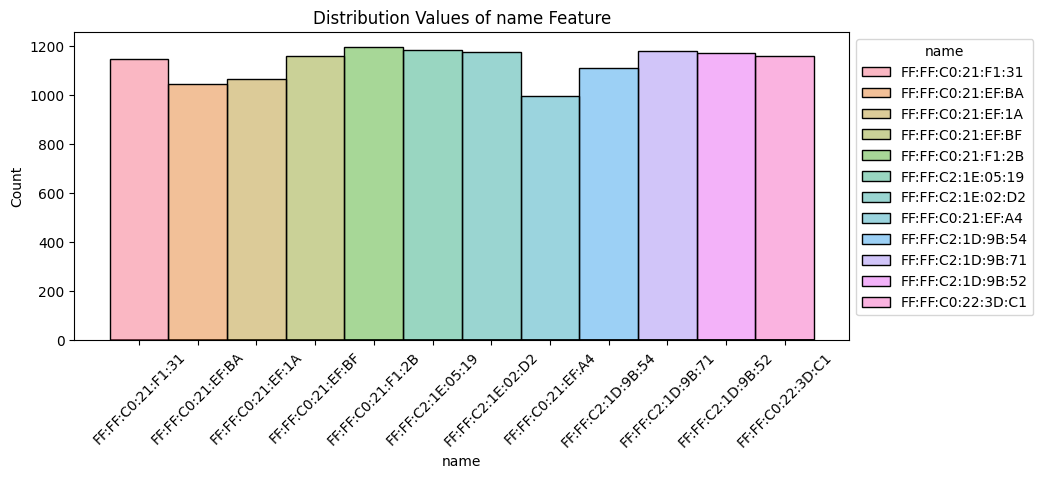

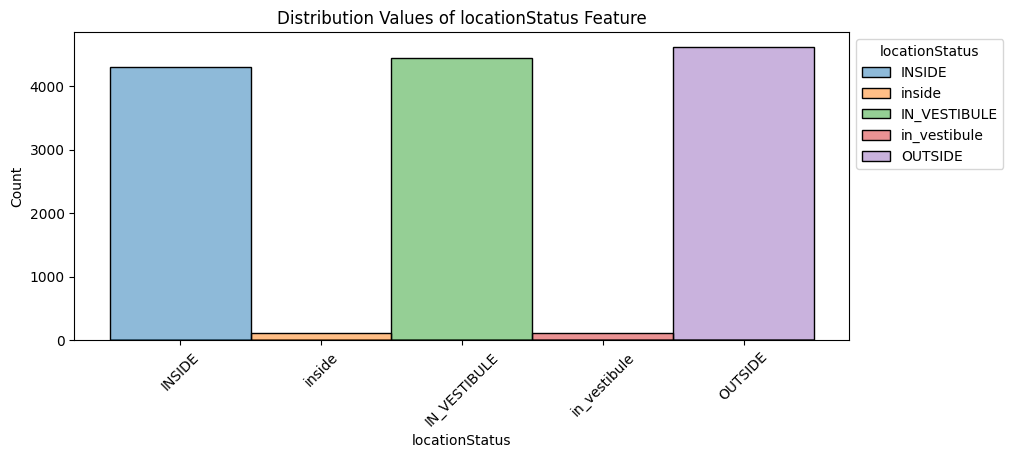

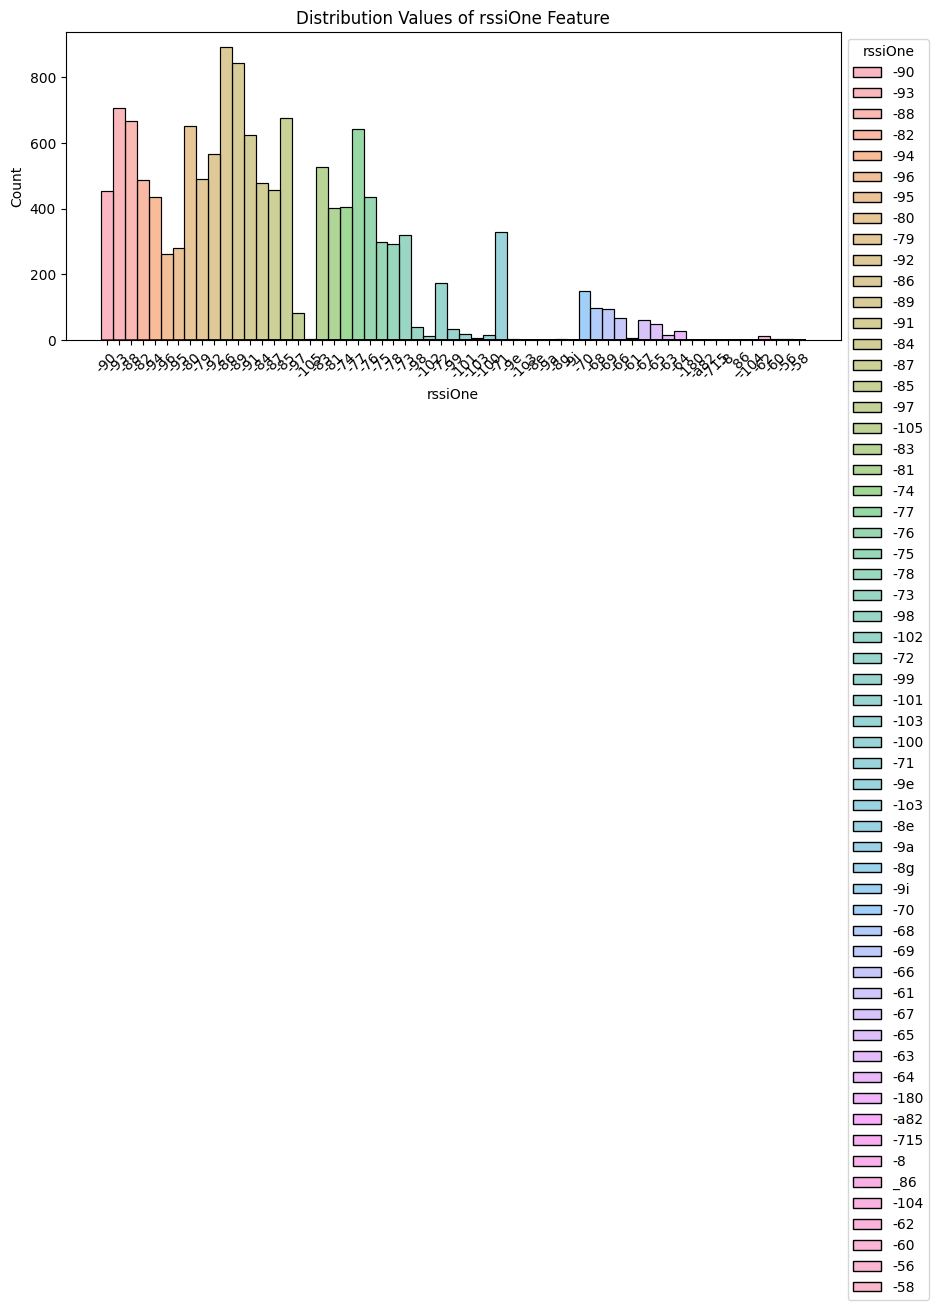

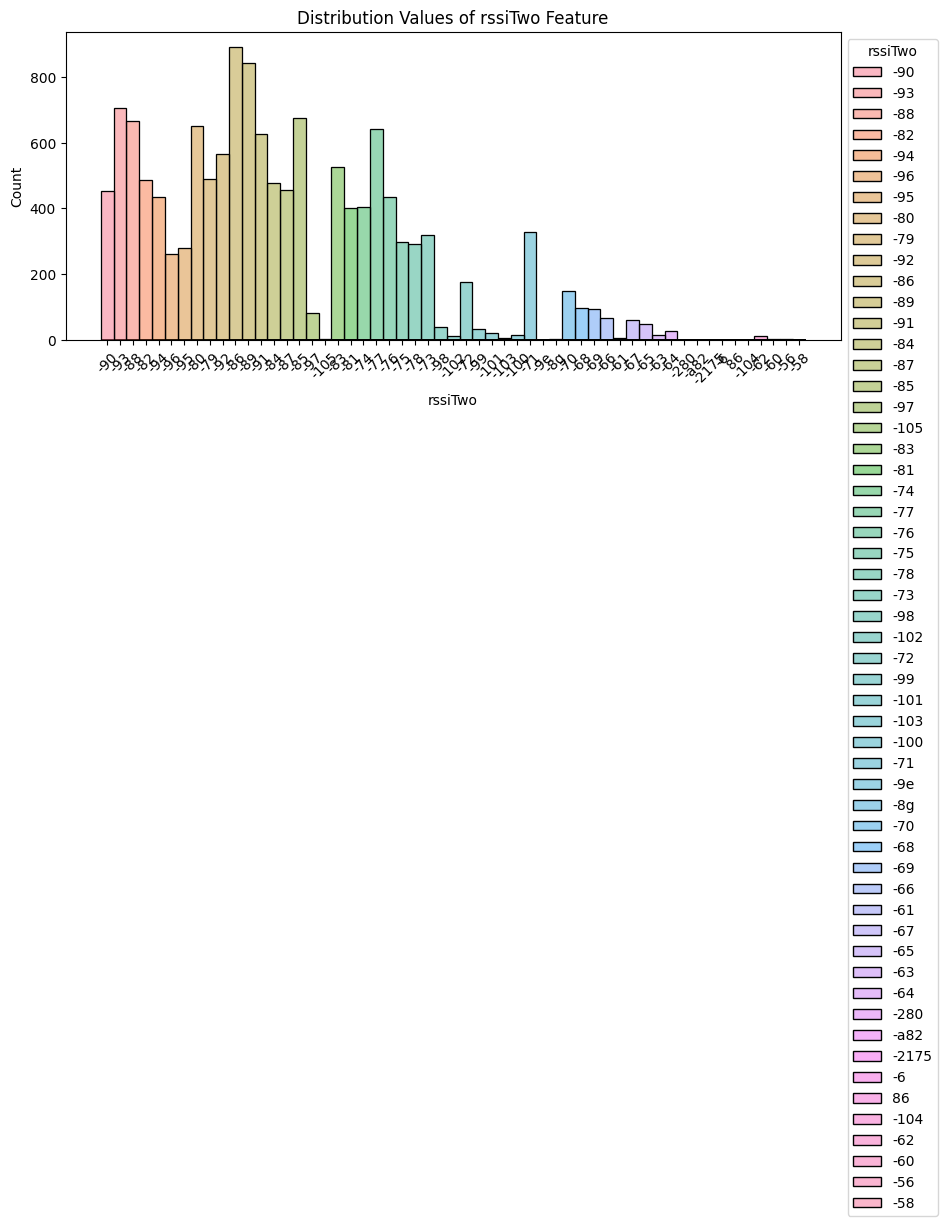

In [161]:
for col in cat_cols:
    plt.figure(figsize=( 10,4))
    plt.xticks(rotation=45)
    ax = sns.histplot(data=bt1, x=col, kde=True, hue=col)
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))
    plt.title(f'Distribution Values of {col} Feature')
    plt.show()

### 2.3 Bivariate Analysis

#### Distribution Independet Features vs Target

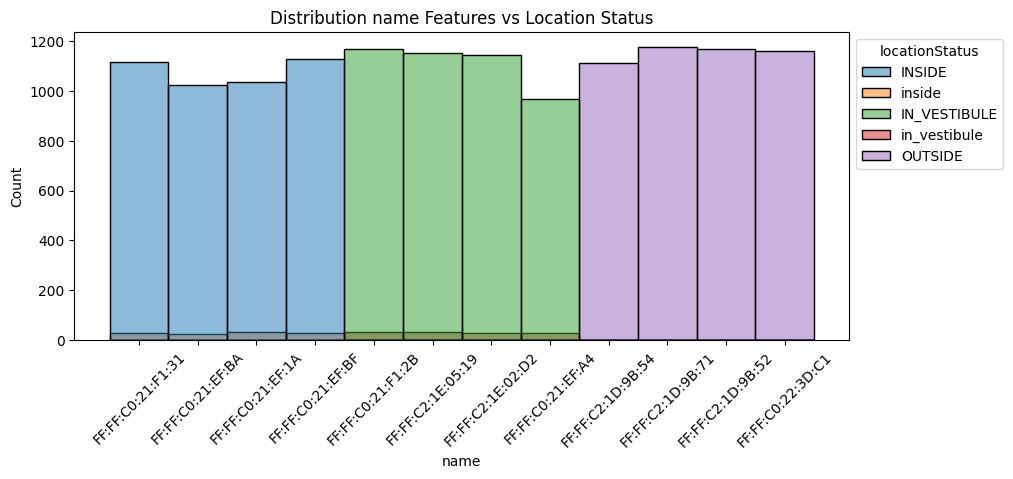

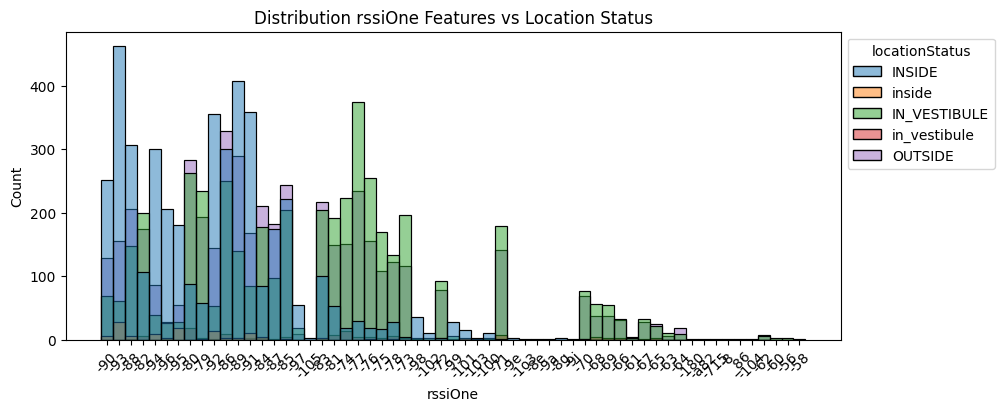

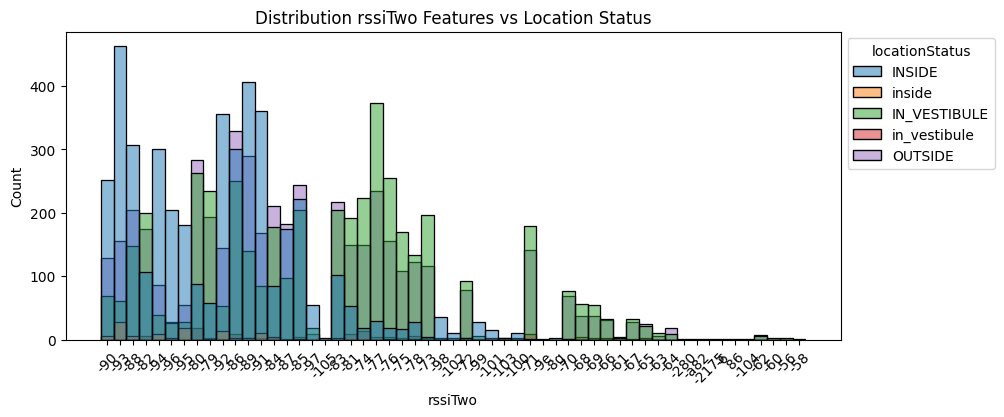

In [162]:
for col in cat_cols:
    if col == 'locationStatus':
        continue
    plt.figure(figsize=(10, 4))
    plt.xticks(rotation=45)
    ax = sns.histplot(data=bt1, x=col, hue='locationStatus')
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))
    plt.title(f'Distribution {col} Features vs Location Status')
    plt.show()

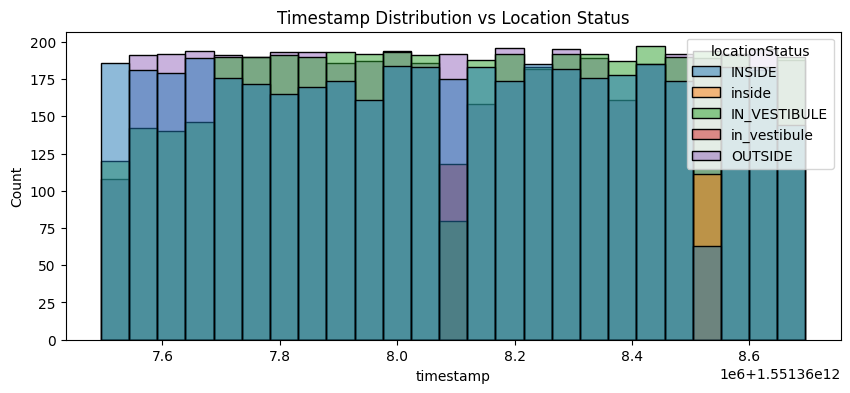

In [163]:
plt.figure(figsize=(10, 4))
sns.histplot(data=bt1, x='timestamp', hue='locationStatus')
plt.title('Timestamp Distribution vs Location Status')
plt.show()

## 3. Data Preprocessing

### 3.1 Handiling Duplicated Data


In [164]:
# Drop the duplicated data
bt1 = bt1.drop_duplicates(keep='first')
print('\nNumber of duplicated data:', bt1.duplicated().sum())


Number of duplicated data: 0


### 3.2 Cleaning Data

In [165]:
# Set the 'locationStatus' to uppercase 
bt1['locationStatus'] = bt1['locationStatus'].str.upper()
bt1['locationStatus'].unique()

<StringArray>
['INSIDE', 'IN_VESTIBULE', 'OUTSIDE']
Length: 3, dtype: str

### 3.3 Handling Inconsistent Data

In [166]:
bt1.columns

Index(['name', 'locationStatus', 'timestamp', 'rssiOne', 'rssiTwo',
       'datetime'],
      dtype='str')

In [167]:
columns = ['rssiOne', 'rssiTwo']
for col in columns:
    bt1[col] = pd.to_numeric(bt1[col], errors='coerce')
    jumlah_rusak = bt1[col].isna().sum()
    median_val = bt1[col].median()
    bt1[col] = bt1[col].fillna(median_val).astype(float)
    print(f'\nAda {jumlah_rusak} data rusak pada fitur {col}.')


Ada 10 data rusak pada fitur rssiOne.

Ada 5 data rusak pada fitur rssiTwo.


In [168]:
for col in columns:
    print(f'{col}:', bt1[col].unique())

rssiOne: [ -90.  -93.  -88.  -82.  -94.  -96.  -95.  -80.  -79.  -92.  -86.  -89.
  -91.  -84.  -87.  -85.  -97. -105.  -83.  -81.  -74.  -77.  -76.  -75.
  -78.  -73.  -98. -102.  -72.  -99. -101. -103. -100.  -71.  -70.  -68.
  -69.  -66.  -61.  -67.  -65.  -63.  -64. -180. -715.   -8. -104.  -62.
  -60.  -56.  -58.]
rssiTwo: [  -90.   -93.   -88.   -82.   -94.   -96.   -95.   -80.   -79.   -92.
   -86.   -89.   -91.   -84.   -87.   -85.   -97.  -105.   -83.   -81.
   -74.   -77.   -76.   -75.   -78.   -73.   -98.  -102.   -72.   -99.
  -101.  -103.  -100.   -71.   -70.   -68.   -69.   -66.   -61.   -67.
   -65.   -63.   -64.  -280. -2175.    -6.    86.  -104.   -62.   -60.
   -56.   -58.]


In [169]:
bt1[columns].describe()

,rssiOne,rssiTwo
count,10759.000000,10759.000000
mean,-83.156706,-83.289339
std,9.759336,21.687402
min,-715.000000,-2175.000000
25%,-89.000000,-89.000000
50%,-84.000000,-84.000000
75%,-77.000000,-77.000000
max,-8.000000,86.000000


In [170]:
bt1.info()

<class 'pandas.DataFrame'>
Index: 10759 entries, 0 to 13587
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   name            10759 non-null  str           
 1   locationStatus  10759 non-null  str           
 2   timestamp       10759 non-null  int64         
 3   rssiOne         10759 non-null  float64       
 4   rssiTwo         10759 non-null  float64       
 5   datetime        10759 non-null  datetime64[ms]
dtypes: datetime64[ms](1), float64(2), int64(1), str(2)
memory usage: 588.4 KB


### 3.4 Encoding the Target Feature

In [171]:
# Encoding using mapping technique
bt1['locationStatus'] = bt1['locationStatus'].map({'INSIDE':0, 'IN_VESTIBULE':1, 'OUTSIDE':2})
bt1['locationStatus'].unique()

array([0, 1, 2])

In [172]:
sensor_list = bt1['name'].unique().tolist()
mapping_sensor = {nama: index for index, nama in enumerate(sensor_list)}
bt1['name'] = bt1['name'].map(mapping_sensor)

print("Mapping 12 Sensor:")
for nama, kode in mapping_sensor.items():
    print(f"{nama} -> {kode}")

Mapping 12 Sensor:
FF:FF:C0:21:F1:31 -> 0
FF:FF:C0:21:EF:BA -> 1
FF:FF:C0:21:EF:1A -> 2
FF:FF:C0:21:EF:BF -> 3
FF:FF:C0:21:F1:2B -> 4
FF:FF:C2:1E:05:19 -> 5
FF:FF:C2:1E:02:D2 -> 6
FF:FF:C0:21:EF:A4 -> 7
FF:FF:C2:1D:9B:54 -> 8
FF:FF:C2:1D:9B:71 -> 9
FF:FF:C2:1D:9B:52 -> 10
FF:FF:C0:22:3D:C1 -> 11


In [173]:
bt1.head()

,name,locationStatus,timestamp,rssiOne,rssiTwo,datetime
0,0,0,1551367495147,-90.0,-90.0,2019-02-28 15:24:55.147
1,1,0,1551367496681,-93.0,-93.0,2019-02-28 15:24:56.681
2,2,0,1551367495114,-88.0,-88.0,2019-02-28 15:24:55.114
3,3,0,1551367497508,-82.0,-82.0,2019-02-28 15:24:57.508
4,0,0,1551367496906,-94.0,-94.0,2019-02-28 15:24:56.906


In [174]:
bt1['name'].value_counts()

name
9     1132
10    1118
11    1053
4     1041
6     1002
8      980
7      854
5      844
3      797
0      740
2      688
1      510
Name: count, dtype: int64

In [175]:
bt1 = bt1.drop_duplicates(keep='first')
bt1.duplicated().sum()

np.int64(0)

In [176]:
bt1.head()

,name,locationStatus,timestamp,rssiOne,rssiTwo,datetime
0,0,0,1551367495147,-90.0,-90.0,2019-02-28 15:24:55.147
1,1,0,1551367496681,-93.0,-93.0,2019-02-28 15:24:56.681
2,2,0,1551367495114,-88.0,-88.0,2019-02-28 15:24:55.114
3,3,0,1551367497508,-82.0,-82.0,2019-02-28 15:24:57.508
4,0,0,1551367496906,-94.0,-94.0,2019-02-28 15:24:56.906


### 3.5 Independent & Dependent

In [177]:
X = bt1.drop(['locationStatus', 'datetime'], axis=1)
y = bt1['locationStatus']

### 3.6 Split Data

In [178]:
def split_data(X, y, size=0.8):
    np.random.seed(42)

    train_idx, test_idx = [], []

    for i in np.unique(y):
        idx = np.where(y == i)[0]
        idx = np.random.permutation(idx)
        
        split = int(len(idx) * size)

        train_idx.extend(idx[:split])
        test_idx.extend(idx[split:])

    return X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]


In [179]:
X_train, X_test, y_train, y_test = split_data(X, y)
for val in [X_train, X_test, y_train, y_test]:
    print(val.shape)

(8601, 4)
(2152, 4)
(8601,)
(2152,)


## 4. Model 

### 4.1 Decision Tree

In [210]:
class Node:
    def __init__(self):
        self.pred_class = None
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None
        self.gini = None

class DTCART:
    def __init__(self, max_depth=5, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_split = min_samples_split
        self.min_leaf = min_samples_leaf
        self.root = None
        self.classes = None

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        self.classes = np.unique(y)
        self.root = self._grow(X, y, 0)
        return self

    def _gini(self, y):
        if len(y) == 0:
            return 0
        probs = np.bincount(y, minlength=len(self.classes)) / len(y)
        return 1 - np.sum(probs ** 2)

    def _split(self, X, y):
        m, n = X.shape
        if m < self.min_split:
            return None, None
        
        best_gini = self._gini(y)
        best_feature, best_threshold = None, None

        for feature in range(n):
            idx = np.argsort(X[:, feature])
            X_sorted, y_sorted = X[idx, feature], y[idx]

            left_counts = np.zeros(len(self.classes), dtype=int)
            right_counts = np.bincount(y_sorted, minlength=len(self.classes))

            for i in range(1, m):
                c = y_sorted[i-1]
                left_counts[c] += 1
                right_counts[c] -= 1

                if X_sorted[i] == X_sorted[i-1]:
                    continue

                if i < self.min_leaf or (m-i) < self.min_leaf:
                    continue

                left_gini = 1 - np.sum((left_counts / i)**2)
                right_gini = 1 - np.sum((right_counts / (m-i))**2)
                gini = (i * left_gini + (m-i) * right_gini) / m

                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_threshold = (X_sorted[i] + X_sorted[i-1]) / 2
        return best_feature, best_threshold

    def _grow(self, X, y, depth):
        node = Node()
        node.pred_class = np.bincount(y).argmax()
        node.gini = self._gini(y)

        if (self.max_depth and depth >= self.max_depth) or len(y) < self.min_split or len(np.unique(y)) == 1:
            return node

        feature, threshold = self._split(X, y)
        if feature is None:
            return node
        
        left_mask = X[:, feature] <= threshold
        if np.sum(left_mask) < self.min_leaf or np.sum(~left_mask) < self.min_leaf:
            return node
        
        node.feature = feature
        node.threshold = threshold
        node.left = self._grow(X[left_mask], y[left_mask], depth + 1)
        node.right = self._grow(X[~left_mask], y[~left_mask], depth + 1)

        return node

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_one(x) for x in X])

    def _predict_one(self, x):
        node = self.root
        while node.left is not None:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return self.classes[node.pred_class]

### 4.2 Random Forest

In [211]:
class RF:
    def __init__(self, n_trees=10, max_features='sqrt', **tree_params):
        self.n_trees = n_trees
        self.max_features = max_features
        self.tree_params = tree_params
        self.trees = []
        self.feature_indices = []

    def fit(self, X, y):
        np.random.seed(42)

        X,y = np.asarray(X), np.asarray(y)
        n_samples, n_features = X.shape

        if self.max_features == 'sqrt':
            max_feat = int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            max_feat = int(np.log2(n_features))
        else:
            max_feat = int(self.max_features)
        
        for _ in range(self.n_trees):
            idx = np.random.choice(n_samples, size=n_samples, replace=True)
            X_boot, y_boot = X[idx], y[idx]

            feat_idx = np.random.choice(n_features, size=max_feat, replace=False)
            X_boot_subset = X_boot[:, feat_idx]

            tree = DTCART(**self.tree_params)
            tree.fit(X_boot_subset, y_boot)

            self.trees.append(tree)
            self.feature_indices.append(feat_idx)
        
        return self

    def predict(self, X):
        X = np.asarray(X)

        all_preds = np.zeros((len(X), self.n_trees), dtype=int)

        for i, (tree, feat_idx) in enumerate(zip(self.trees, self.feature_indices)):
            all_preds[:, i] = tree.predict(X[:, feat_idx])

        return np.array([np.bincount(preds).argmax() for preds in all_preds])

### 4.3 Grid Search

In [182]:
best_depth = None
best_tree = None
best_acc = 0

for depth in [3,4,5,6,7,8,9,10]:
    for tree in [10,20,50,100]:
        model = RF(n_trees=tree, max_features='sqrt', max_depth=depth)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = np.mean(y_test == pred)

        print(f'Depth: {depth} - Akurasi: {acc:.4f} - Tree: {tree}')

        if acc > best_acc:
            best_acc = acc
            best_depth = depth
            best_tree = tree
print(f'Best depth: {best_depth} - Akurasi: {best_acc:.4f} - Best tree: {best_tree}')

Depth: 3 - Akurasi: 0.7825 - Tree: 10
Depth: 3 - Akurasi: 0.7853 - Tree: 20
Depth: 3 - Akurasi: 0.6445 - Tree: 50
Depth: 3 - Akurasi: 0.6789 - Tree: 100
Depth: 4 - Akurasi: 0.7849 - Tree: 10
Depth: 4 - Akurasi: 0.7867 - Tree: 20
Depth: 4 - Akurasi: 0.7059 - Tree: 50
Depth: 4 - Akurasi: 0.7193 - Tree: 100
Depth: 5 - Akurasi: 0.8369 - Tree: 10
Depth: 5 - Akurasi: 0.8397 - Tree: 20
Depth: 5 - Akurasi: 0.7314 - Tree: 50
Depth: 5 - Akurasi: 0.7839 - Tree: 100
Depth: 6 - Akurasi: 0.8453 - Tree: 10
Depth: 6 - Akurasi: 0.8694 - Tree: 20
Depth: 6 - Akurasi: 0.7695 - Tree: 50
Depth: 6 - Akurasi: 0.8127 - Tree: 100
Depth: 7 - Akurasi: 0.8527 - Tree: 10
Depth: 7 - Akurasi: 0.8931 - Tree: 20
Depth: 7 - Akurasi: 0.8099 - Tree: 50
Depth: 7 - Akurasi: 0.8476 - Tree: 100
Depth: 8 - Akurasi: 0.8806 - Tree: 10
Depth: 8 - Akurasi: 0.9205 - Tree: 20
Depth: 8 - Akurasi: 0.8304 - Tree: 50
Depth: 8 - Akurasi: 0.8638 - Tree: 100
Depth: 9 - Akurasi: 0.8694 - Tree: 10
Depth: 9 - Akurasi: 0.9215 - Tree: 20
Depth:

### Implementasi Model

In [220]:
model = RF(n_trees=best_tree, max_features='sqrt', max_depth=best_depth)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

## 5. Evaluation 

In [184]:
def evaluate(y_true, y_pred, title='Train'):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    for i in np.unique(y_true):
        tp = np.sum((y_true == i) & (y_pred == i))
        fp = np.sum((y_true != i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))

        accuracy = np.mean(y_true == y_pred)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f'\nEvluasi Data {title}')
    print(f'Aaccuracy   : {accuracy:.4f}')
    print(f'Precision   : {precision:.4f}')
    print(f'Recall      : {recall:.4f}')
    print(f'F1          : {f1:.4f}')

In [221]:
evaluate(y_train, y_pred_train)
evaluate(y_test, y_pred_test, title='Test')


Evluasi Data Train
Aaccuracy   : 0.9497
Precision   : 1.0000
Recall      : 0.8955
F1          : 0.9449

Evluasi Data Test
Aaccuracy   : 0.9298
Precision   : 1.0000
Recall      : 0.8565
F1          : 0.9227


Evluasi Data Train
- Aaccuracy   : 0.7858
- Precision   : 1.0000
- Recall      : 0.5400
- F1          : 0.7013
 
Evluasi Data Test
- Aaccuracy   : 0.4661
- Precision   : 0.4272
- Recall      : 1.0000
- F1          : 0.5987

## 6. Visualization

#### Confusion Matrix

In [186]:
feature = ['INSIDE','IN_VESTIBULE','OUTSIDE']

def cmtrx(y_true, y_pred, title='Train'):
    classes = np.unique(y_true)
    n_classes = len(classes)

    cm = np.zeros((n_classes, n_classes))

    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm[i, j] = np.sum((y_true == c_true) * (y_pred == c_pred))

    plt.figure(figsize=(10,7))
    plt.title(f'Confusion Matrix {title}', fontsize=17)
    sns.heatmap(cm, annot=True, fmt='.0f', cbar=False, xticklabels=feature, yticklabels=feature, cmap='Blues')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

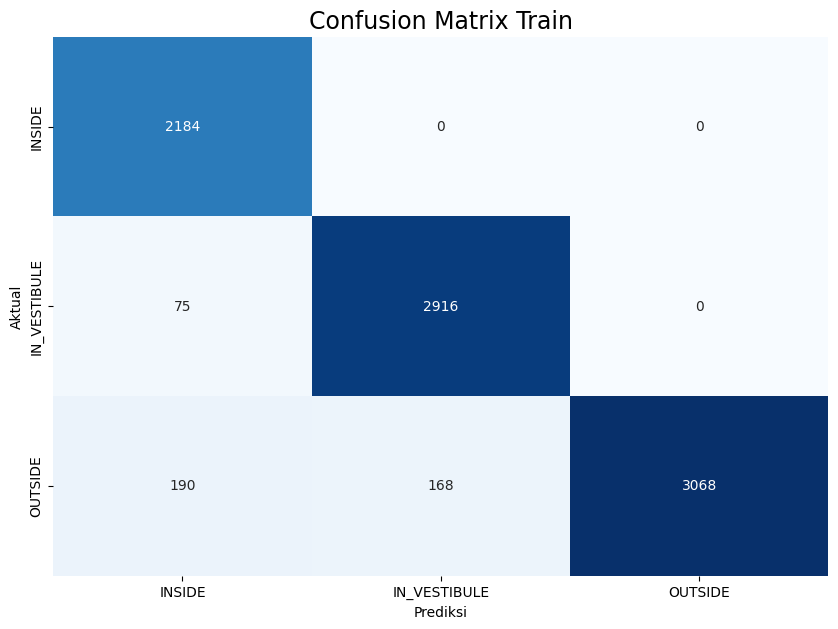

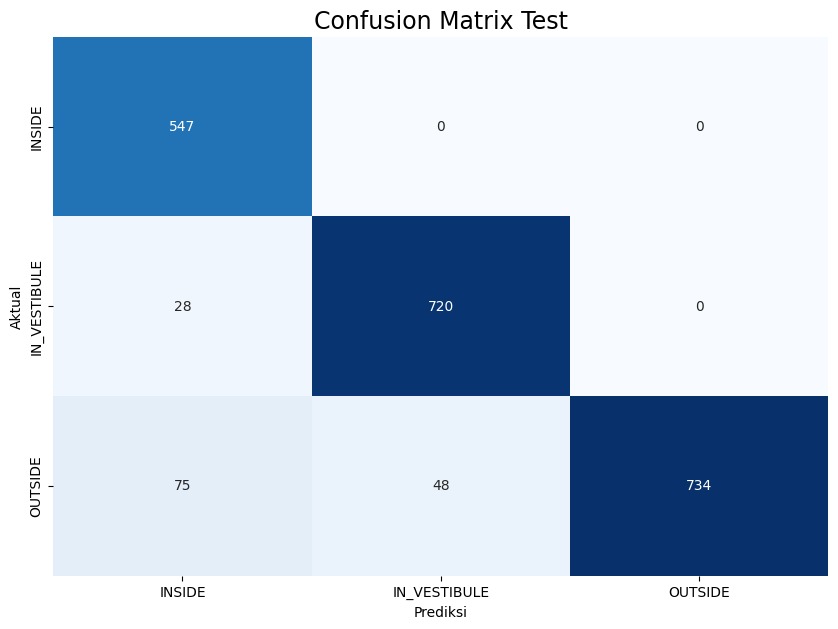

In [187]:
cmtrx(y_train, y_pred_train)
cmtrx(y_test, y_pred_test, title='Test')

#### Tree

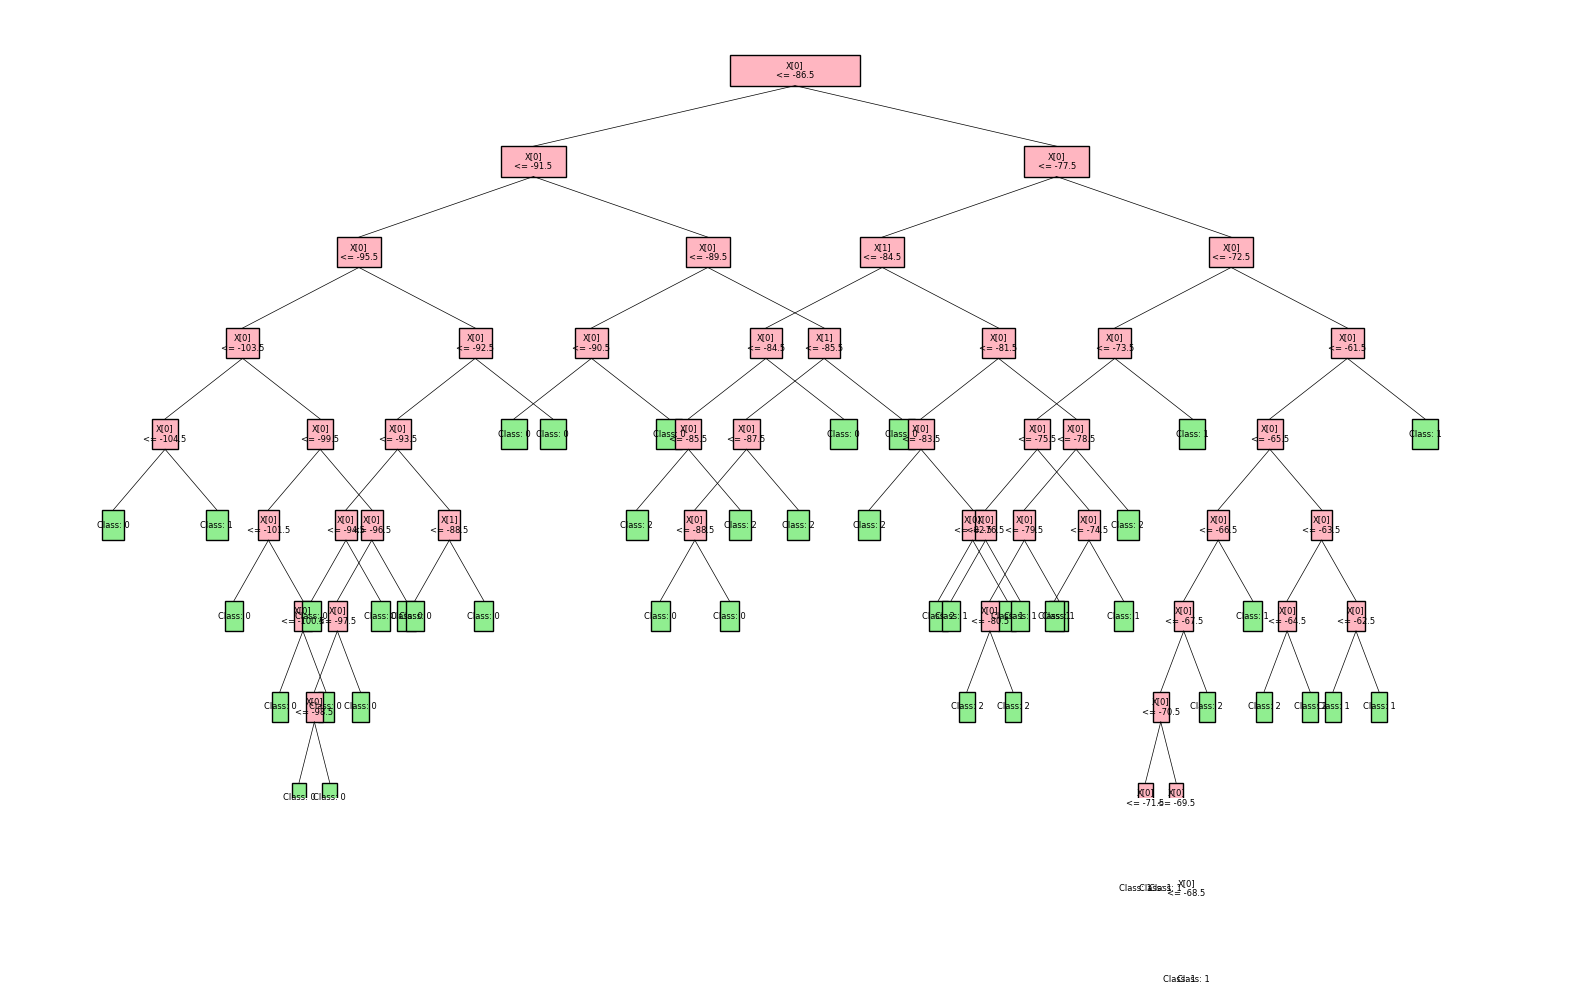

In [214]:
def plot_tree(node, depth=0, x=0, y=0, dx=1, parent_x=None, parent_y=None, ax=None, max_depth=3):
    # stop at max_depth for viz
    if depth > max_depth:
        return ax
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 10))  # bigger figure
        ax.set_xlim(-3, 3)
        ax.set_ylim(-max_depth-2, 1)
        ax.axis('off')
    
    # smaller boxes, adjusted for depth
    box_w = 0.5 / (depth + 1)  
    box_h = 0.5
    
    if node.left is None:
        color = '#90EE90'
        text = f'Class: {node.pred_class}'
    else:
        color = '#FFB6C1'
        text = f'X[{node.feature}]\n<= {node.threshold:.1f}'  # shorter text
    
    # draw
    ax.add_patch(plt.Rectangle((x-box_w/2, y-box_h/2), box_w, box_h,
                                facecolor=color, edgecolor='black'))
    ax.text(x, y, text, ha='center', va='center', fontsize=6)
    
    if parent_x is not None:
        ax.plot([parent_x, x], [parent_y-box_h/2, y+box_h/2], 'k-', lw=0.5)
    
    # recurse with smaller dx
    if node.left is not None:
        plot_tree(node.left, depth+1, x-dx, y-1.5, dx/1.5, x, y, ax, max_depth)
        plot_tree(node.right, depth+1, x+dx, y-1.5, dx/1.5, x, y, ax, max_depth)
    
    return ax

# plot with depth limit
plot_tree(rf.trees[0].root, max_depth=best_depth)
plt.tight_layout()
plt.show()

## 7. GUI

In [226]:
feature_col = X.columns
n_feature = len(feature_col)

def submit():
    try:
        input_data = []
        for i, feature in enumerate(feature_col):
            entry_text = entries[i].get()
            if not entry_text.strip():
                raise ValueError(f'{feature} Gaboleh Kosong')
            input_data.append(float(entry_text))
        
        input_array = np.array([input_data])
        prediction = model.predict(input_array)
        messagebox.showinfo('Done',f'Prediksi: {prediction[0]}')
    except ValueError:
        messagebox.showerror('Error', 'Masukan data yang valid')

root = tk.Tk()
root.title('Prediksi Status Lokasi')
root.configure(bg='#131313')
root.geometry('450x300')
entries = []

frame = tk.Frame(root)
frame.configure(bg='#131313')
frame.place(
    relx=0.5,
    rely=0.45,
    anchor='center'
)

label_title = tk.Label(
    frame,
    text='Prediksi Status Lokasi',
    font=('Helvetica', 18, 'bold'),
    bg='#131313',
    fg='#ffffff'
)
label_title.grid(row=0, column=0, columnspan=2)

label_intruksi = tk.Label(
    frame,
    text='Masukan data dibawah ⬇️',
    font=('Helvetica', 10),
    bg='#131313',
    fg='#737070'
)
label_intruksi.grid(row=1, column=0, columnspan=2, pady=5)

for i, feature in enumerate(feature_col):
    label_fitur = tk.Label(
        frame,
        text=f'{feature}',
        font=('Helvetica', 11),
        bg='#131313',
        fg='#ffffff'
    )
    label_fitur.grid(row=i+2, column=0, pady=5)

    entry = tk.Entry(
        frame,
        font=('Helvetica', 11),
        bg='#4d4b4b',
        fg='#ffffff'
    )
    entry.grid(row=i+2, column=1)
    entries.append(entry)

button = tk.Button(
    frame,
    text='Prediksi',
    font=('Helvetica', 18),
    fg='#ffffff',
    bg='#003087',
    activebackground='#003087',
    bd=0,
    command=submit
)
button.grid(row=6, columnspan=2, pady=5)

root.mainloop()

In [225]:
bt1.sample(5)

,name,locationStatus,timestamp,rssiOne,rssiTwo,datetime
1482,0,0,1551367896179,-95.0,-95.0,2019-02-28 15:31:36.179
988,2,0,1551367756113,-94.0,-94.0,2019-02-28 15:29:16.113
12757,9,2,1551368486076,-87.0,-87.0,2019-02-28 15:41:26.076
13072,10,2,1551368566569,-79.0,-79.0,2019-02-28 15:42:46.569
11141,11,2,1551368063112,-72.0,-72.0,2019-02-28 15:34:23.112
